In [2]:
import warnings
warnings.filterwarnings(action='ignore')
import hybrid_surrogate_server as server

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## hybrid

{'answer': 'Ran the hybrid model, saved the plots for the hybrid model, saved the predicted trajectories.',
 'metadata': {'R2 for test samples': [0.8940088385920059,
   0.9243502834432225,
   0.7384039466000143,
   0.9938316424560563],
  'Days of switch for test samples': [4, 10, 4, 10],
  'Path to the saved figure': 'imgs//run_hybrid_model.png',
  'Path to the saved results': 'hybrid_surr//num_exp//results/example'}}

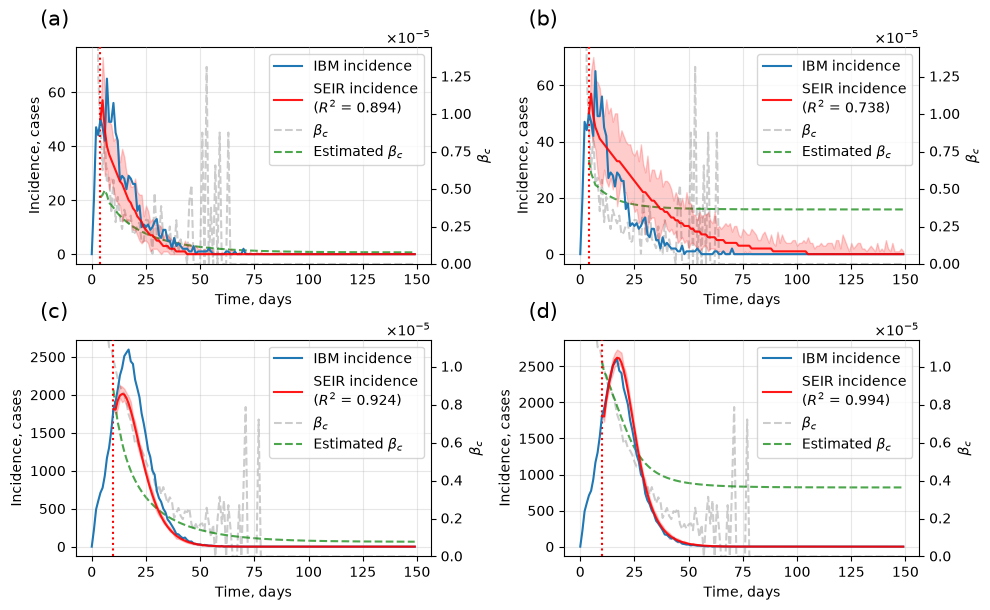

In [4]:
# paper: fig.8
seir_df_paths=\
    ['hybrid_surr/num_exp/net_data/ba_seir/p_0.13_0.3_0.2_0.0001_0.39_seed_0.csv',
    'hybrid_surr/num_exp/net_data/ba_seir/p_0.99_0.3_0.2_0.0001_0.63_seed_0.csv']
server.run_hybrid_model(sigma=0.3, gamma=0.2, 
               switch_I_fraction=0.05, n_hybrid_runs=20, 
               topology='ba', 
              beta_pred=['regression beta', 'lstm'],
              seir_df_paths=seir_df_paths,
                save_results = True,
              res_folder_name='example',
              show_plots = True)

{'answer': 'Created the heatmap plot for the hybrid model.',
 'metadata': {'Path to the saved figure': 'imgs//hybrid_heatmap_r2.png'}}

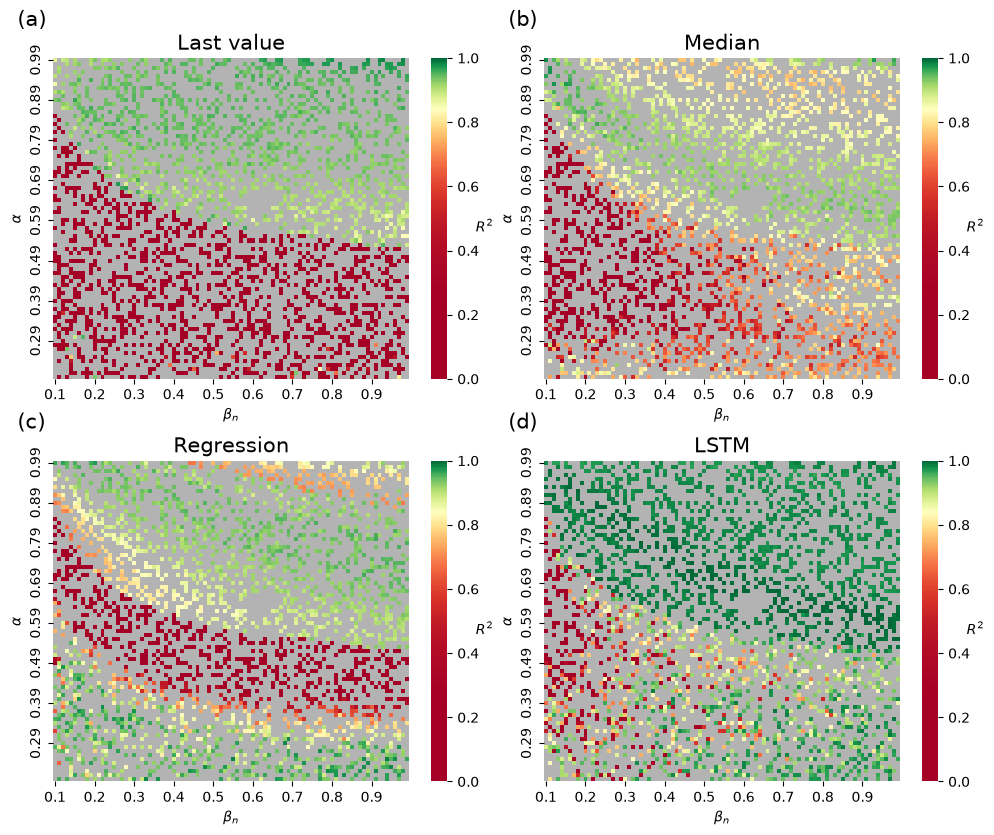

In [3]:
# paper: fig.6
server.hybrid_heatmap_r2(topology='ba')

## surrogate

Due to fast computation time, we do not save the results of the surrogate model. All functions for creating plots use 'predict' inside.

{'answer': 'Created a 2x2 plot for the surrogate model with point estimation.',
 'metadata': {'R2 for test samples': [0.9061567187309265,
   0.9836651682853699,
   0.9941647052764893,
   0.9818785786628723],
  'Path to the saved figure': 'imgs//surrogate_point.png'}}

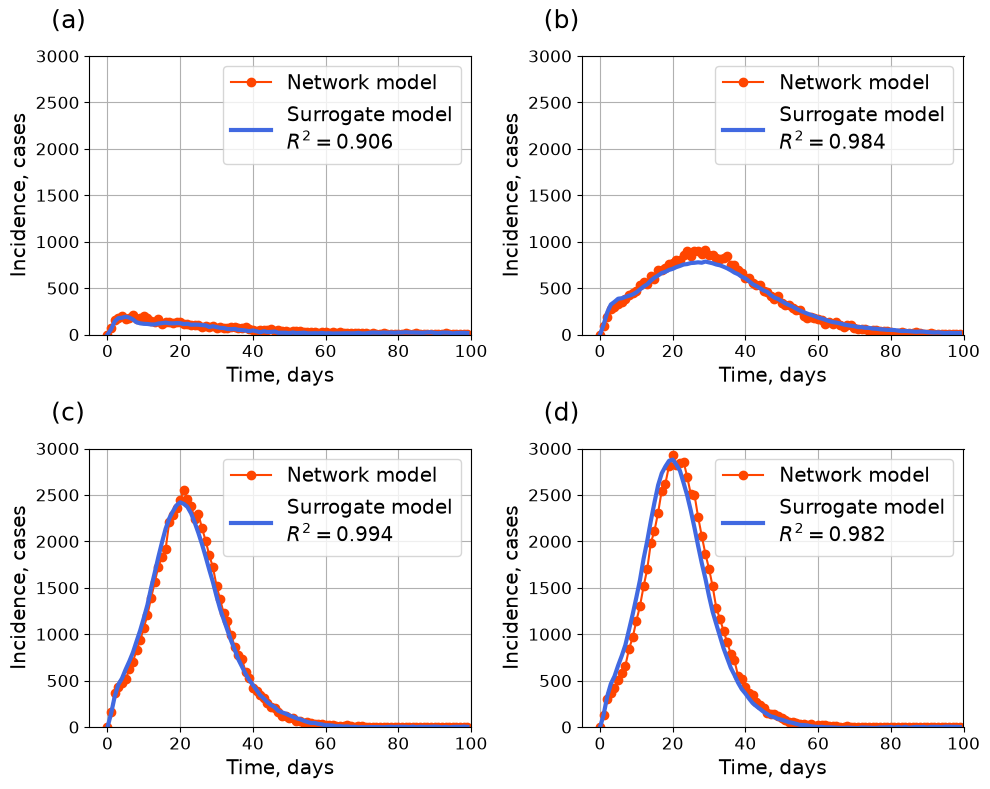

In [4]:
# paper: fig.9
server.run_surrogate_point(topology='ba',
                           alphas = [0.44, 0.59, 0.71, 0.75],
                          betas = [0.35, 0.4 , 0.41, 0.37]
                    )

{'answer': 'Created the 2x2 plot for the surrogate model with interval estimation.',
 'metadata': {'R2 for test samples': [0.9606196540420406,
   0.9777136479021296,
   0.9948103364693667,
   0.9943745901382367],
  'Path to the saved figure': 'imgs//surrogate_interval.png'}}

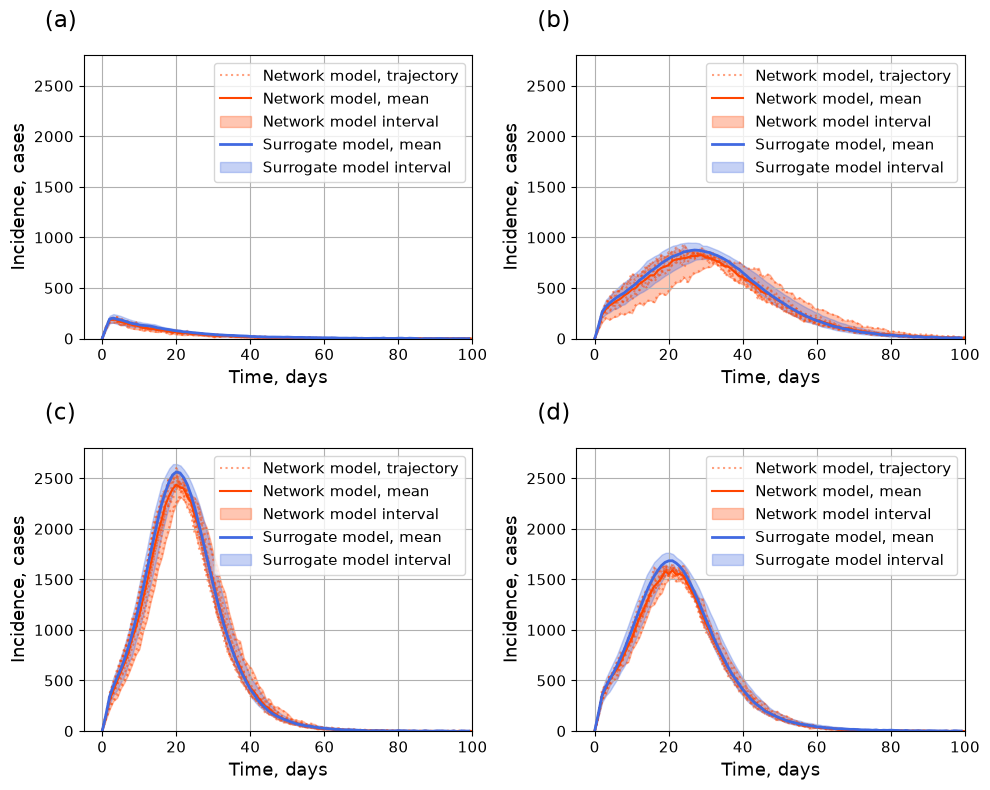

In [5]:
# paper: fig.11
server.run_surrogate_interval(topology='ba',
                          alphas=[0.32, 0.59, 0.71, 0.6 ],
                        betas = [0.83, 0.4 , 0.41, 0.66],
                    ) 

{'answer': 'Created the heatmap plot for the surrogate model.',
 'metadata': {'Path to the saved figure': 'imgs//surrogate_heatmap_r2.png'}}

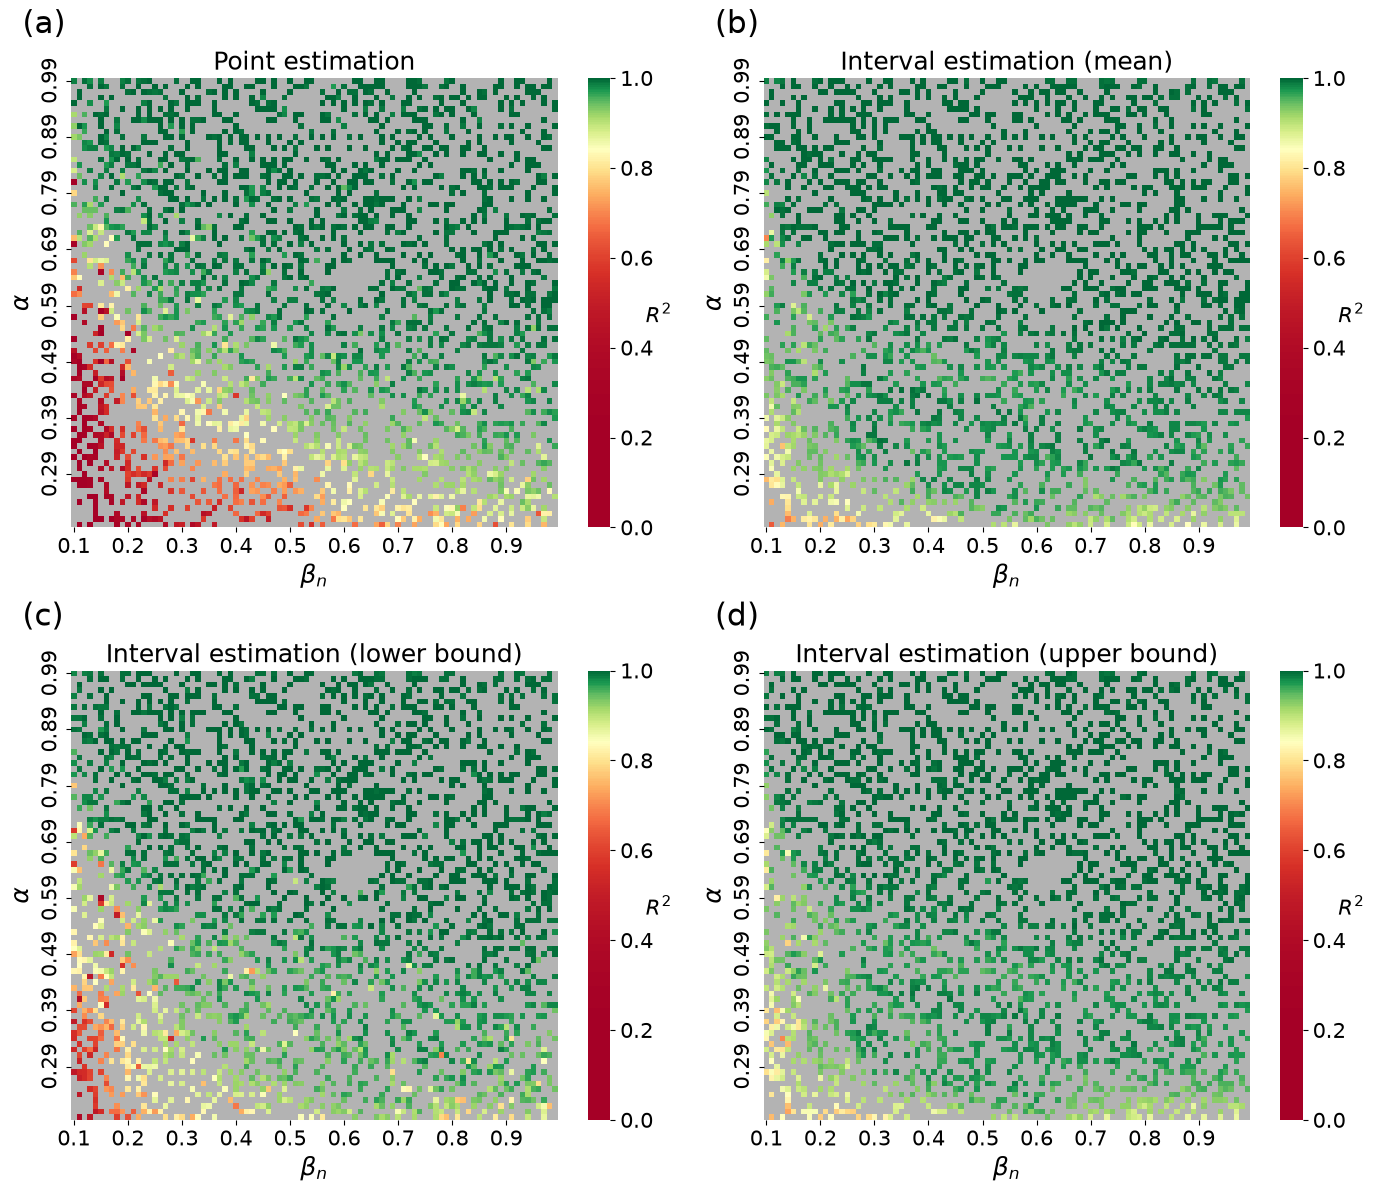

In [6]:
# paper: fig.12
server.surrogate_heatmap_r2(topology='ba')

## calibrating and forecasting

{'answer': 'Calibrated the surrogate model and created the plot.',
 'metadata': {'Selected alpha value': 0.8855652941232481,
  'Selected beta value': 0.1512882948042508,
  'Best R2': 0.9846713542938232,
  'Path to the saved figure': 'imgs//calibrate_model_complete_data.png'}}

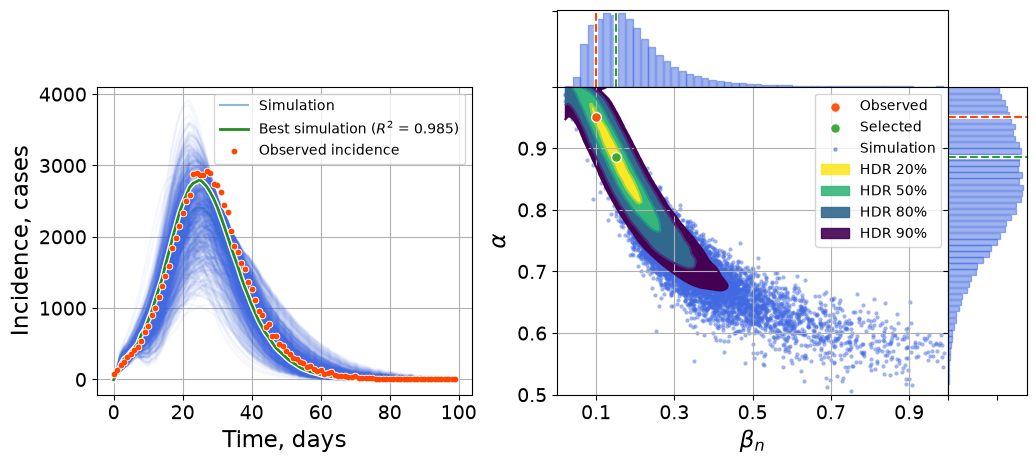

In [22]:
# show calibration for one model
server.calibrate_model_complete_data(model_name='surrogate',
                    n_network_runs=1, show_surr_nth_line=50,
                    sigma=0.3, gamma=0.2,
                    true_alpha = 0.95,true_beta = 0.1,
                    switch_I_fraction=0.05, n_nodes=100000,
                    topology='ba')

{'answer': 'Calibrated the network, hybrid and surrogate models and created the plot.',
 'metadata': {'Selected alpha values': [0.8760162288835825,
   0.8945333434284561,
   0.8855652941232481],
  'Selected beta values': [0.1615659924746181,
   0.149405969205227,
   0.1512882948042508],
  'Best R2': [0.9609491577928867, 0.9815574637062133, 0.9846713542938232],
  'Path to the saved figure': 'imgs//calibrate_model_complete_data_3in1.png'}}

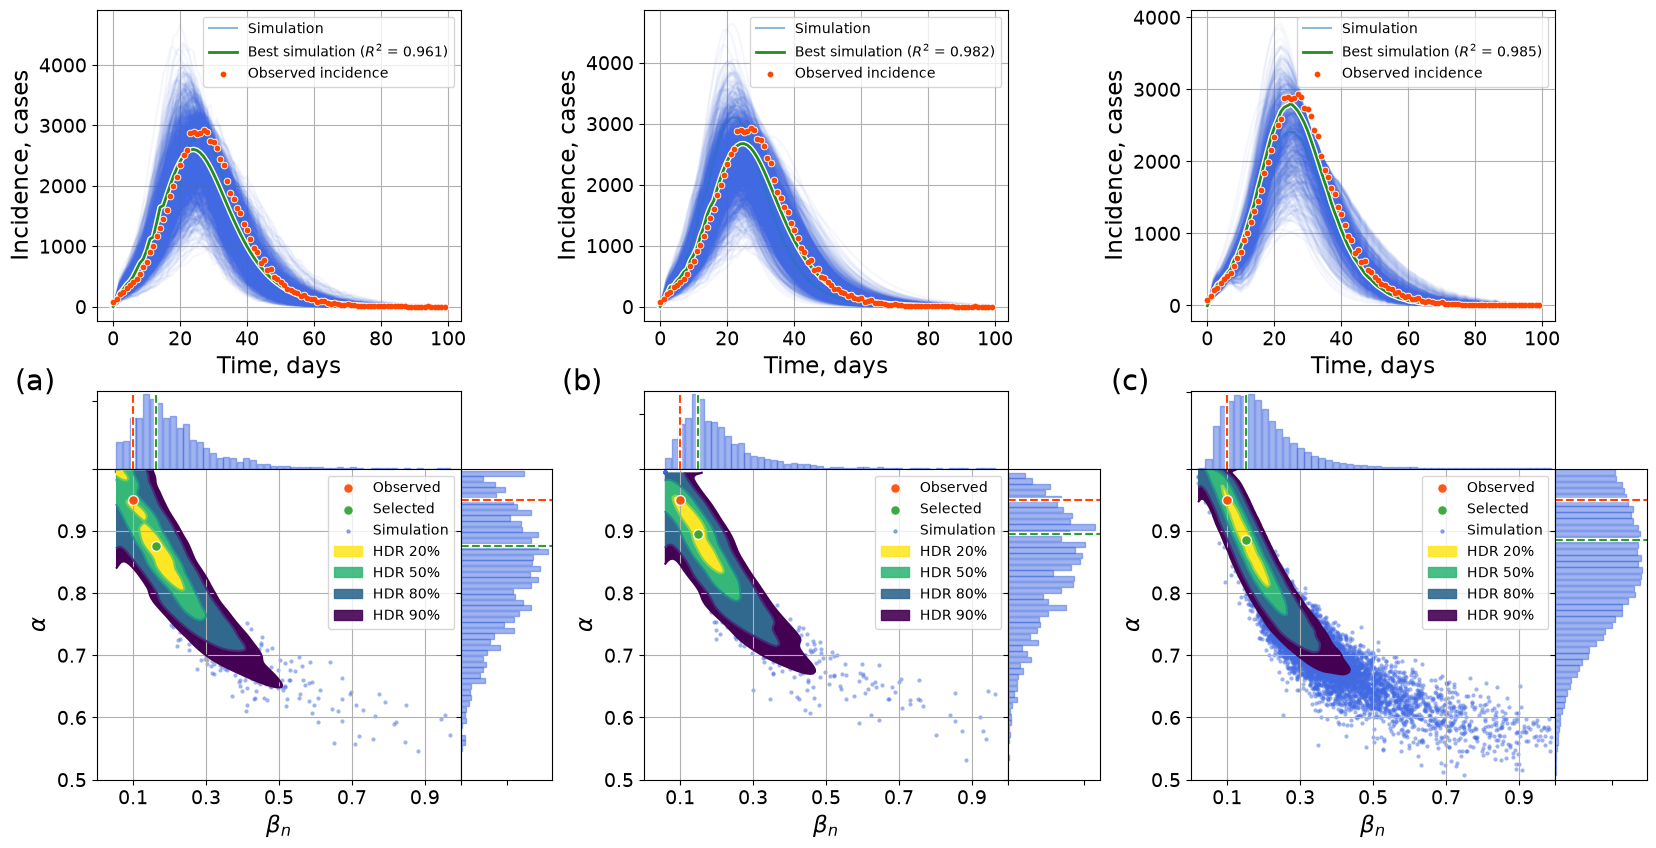

In [21]:
# paper: fig.13 (paper version is done with n_network_runs=50, show_surr_nth_line=1)
server.calibrate_model_complete_data_3in1(n_network_runs=1, 
                                          show_surr_nth_line=50,
                    sigma=0.3, gamma=0.2,
                    true_alpha = 0.95,true_beta = 0.1,
                    switch_I_fraction=0.05, n_nodes=100000,
                    topology='ba')

{'answer': 'Forecasted with the surrogate model and created the plot.',
 'metadata': {'Selected alpha value': 0.736795497156399,
  'Selected beta value': 0.2779829297126548,
  'Path to the saved figure': 'imgs//calibrate_model_forecast.png'}}

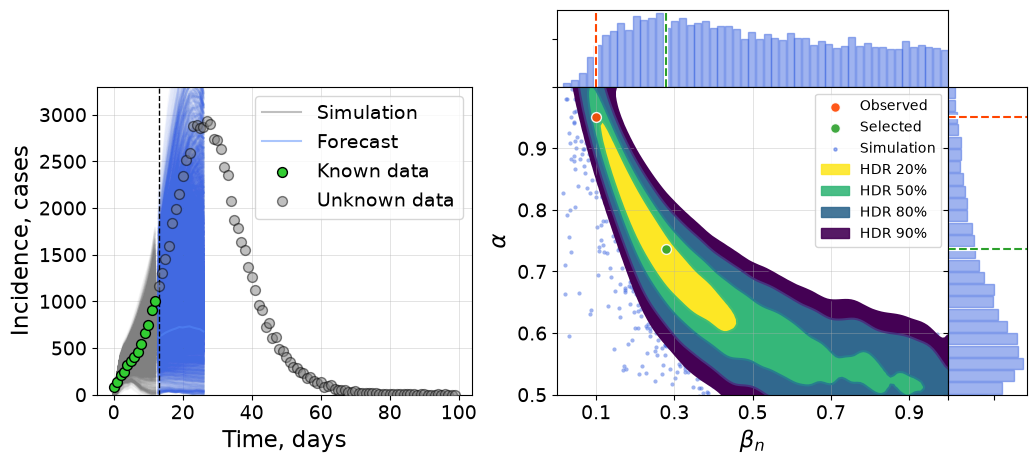

In [15]:
# show forecast for one model
server.calibrate_model_forecast(model_name='surrogate',
                    show_surr_nth_line=10,
                    start_forecasting='14b',
                    sigma=0.3, gamma=0.2,
                    true_alpha = 0.95,true_beta = 0.1,
                    switch_I_fraction=0.05, n_nodes=100000,
                    topology='ba')

{'answer': 'Forecasted with the hybrid model and created the plot.',
 'metadata': {'Selected alpha values': [0.7018917114413784,
   0.7423251112435076,
   0.9556286086094852],
  'Selected beta values': [0.3319899334904737,
   0.3124724971578574,
   0.09926934980124971],
  'Path to the saved figure': 'imgs//calibrate_model_forecast_3in1.png'}}

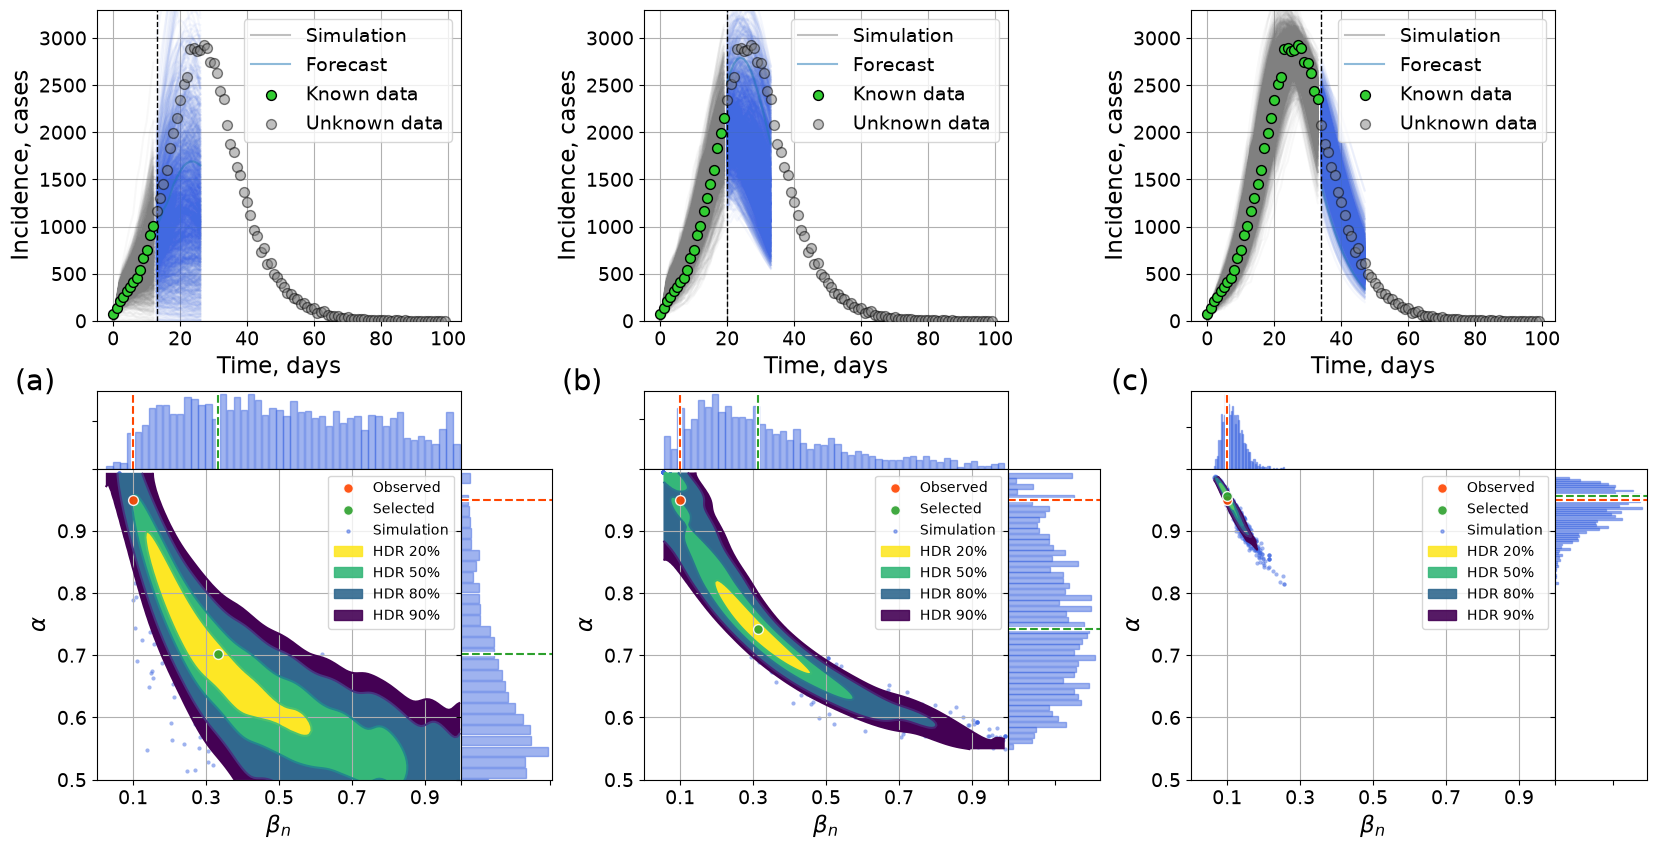

In [10]:
# paper: figs.14, 15
server.calibrate_model_forecast_3in1(model_name='hybrid',
                    show_surr_nth_line=5,
                    sigma=0.3, gamma=0.2,
                    true_alpha = 0.95,true_beta = 0.1,
                    switch_I_fraction=0.05, n_nodes=100000,
                    topology='ba')

{'answer': 'Forecasted with the surrogate model and created the plot.',
 'metadata': {'Selected alpha values': [0.736795497156399,
   0.731988870708796,
   0.9358820465310027],
  'Selected beta values': [0.2779829297126548,
   0.31522334807411323,
   0.1126073935940733],
  'Path to the saved figure': 'imgs//calibrate_model_forecast_3in1.png'}}

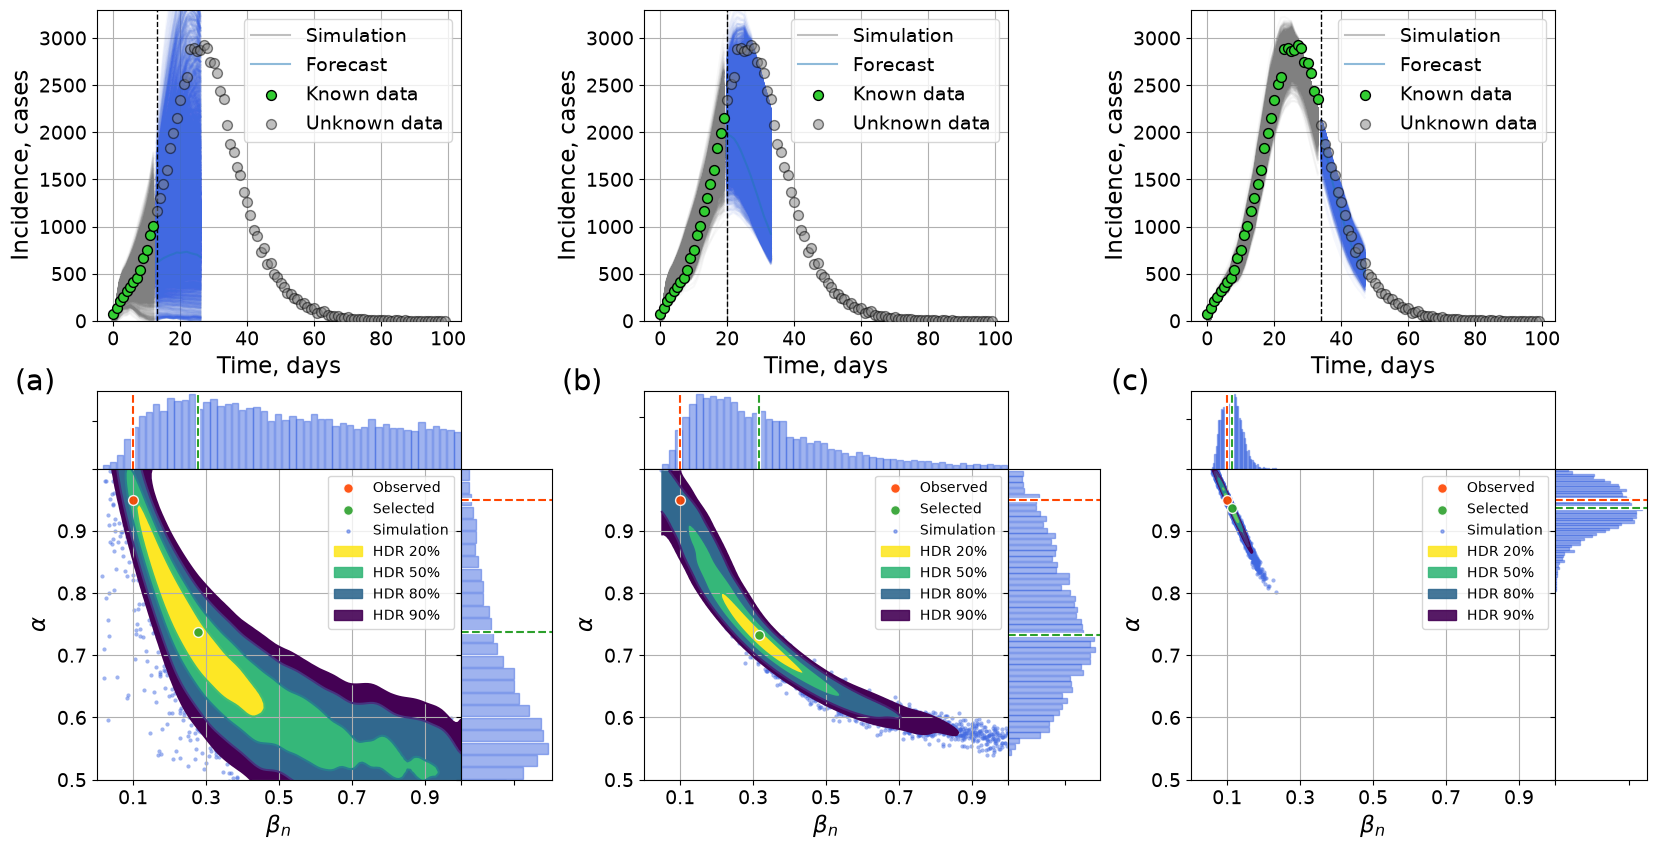

In [11]:
# paper: figs.14, 15
server.calibrate_model_forecast_3in1(model_name='surrogate',
                    show_surr_nth_line=5,
                    sigma=0.3, gamma=0.2,
                    true_alpha = 0.95,true_beta = 0.1,
                    switch_I_fraction=0.05, n_nodes=100000,
                    topology='ba')

## Aux plots

{'answer': 'Created the heatmaps showing the distribution of peak time and peak incidence.',
 'metadata': {'Path to the saved figure': 'imgs//plot_synth_peaks.png'}}

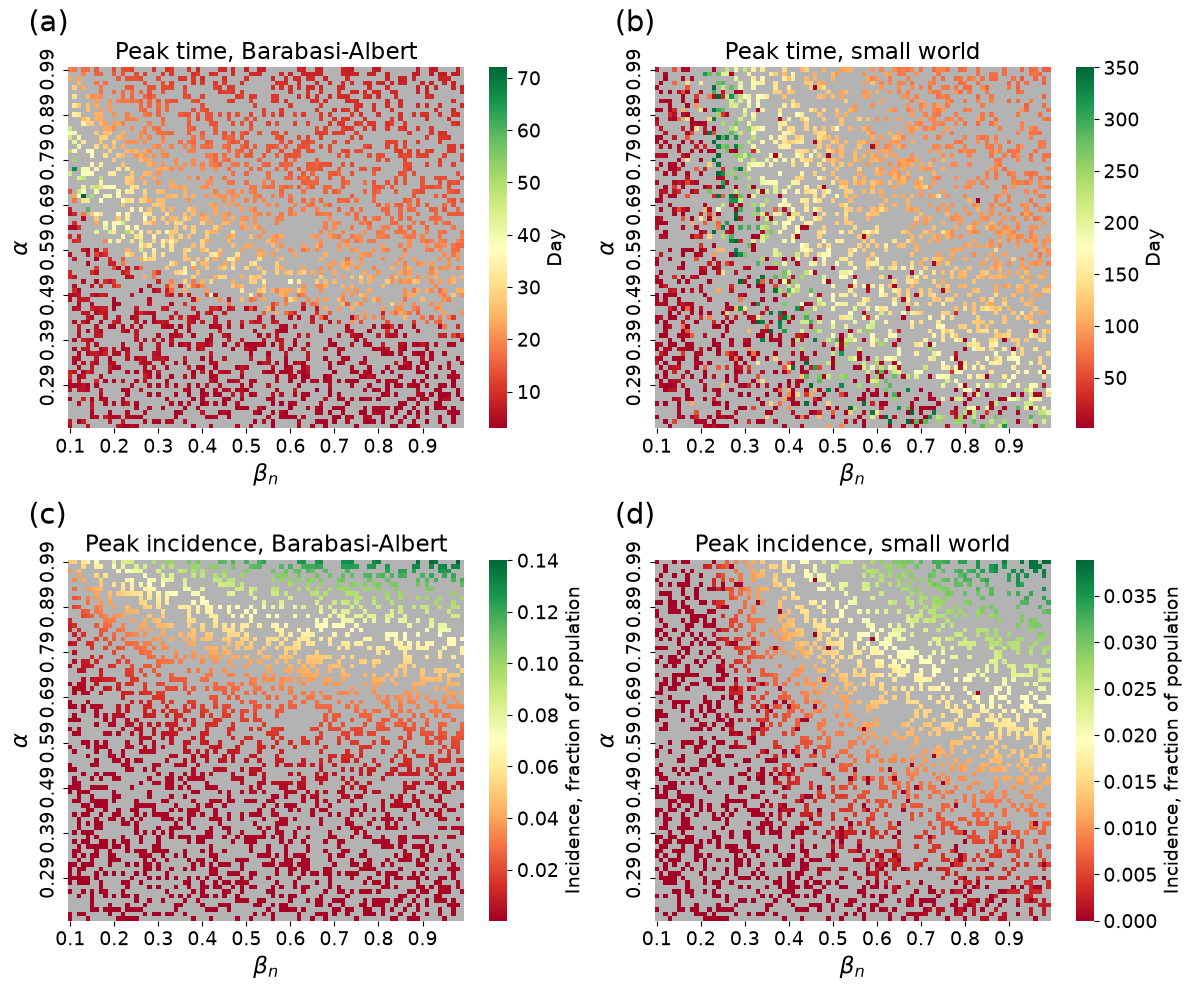

In [24]:
# paper: fig.3
server.plot_synth_peaks()

{'answer': 'Created the plot showing incidence and beta trajectories.',
 'metadata': {'Paths to the saved figures': ['imgs//plot_synth_inc.png',
   'imgs//plot_synth_beta.png']}}

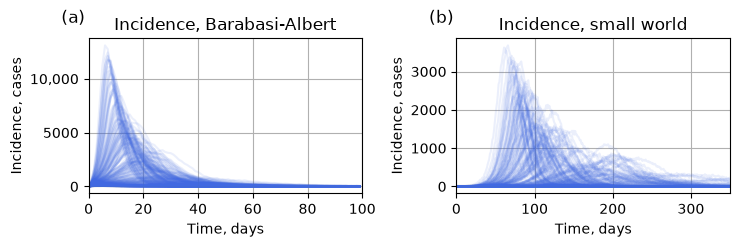

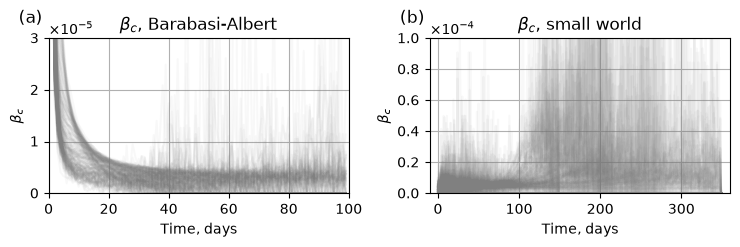

In [25]:
# paper: figs.2, 4
server.plot_synth_inc_beta()

{'answer': 'Created the plot showing peak errors for hybrid and surrogate approaches for short-term forecasting.',
 'metadata': {'Path to the saved figure': 'imgs//plot_forecast_peak_errors.png'}}

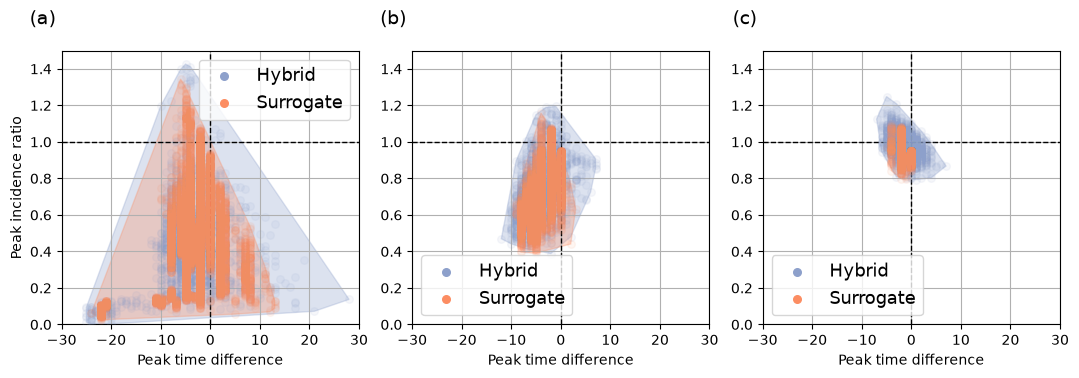

In [26]:
# paper: fig.16
server.plot_forecast_peak_errors(true_alpha= 0.95,
                              true_beta = 0.1,
                              topology='ba')
                             

{'answer': 'Created the plot showing switching behavior for test samples.',
 'metadata': {'Path to the saved figure': 'imgs//plot_heatmap_switch.png'}}

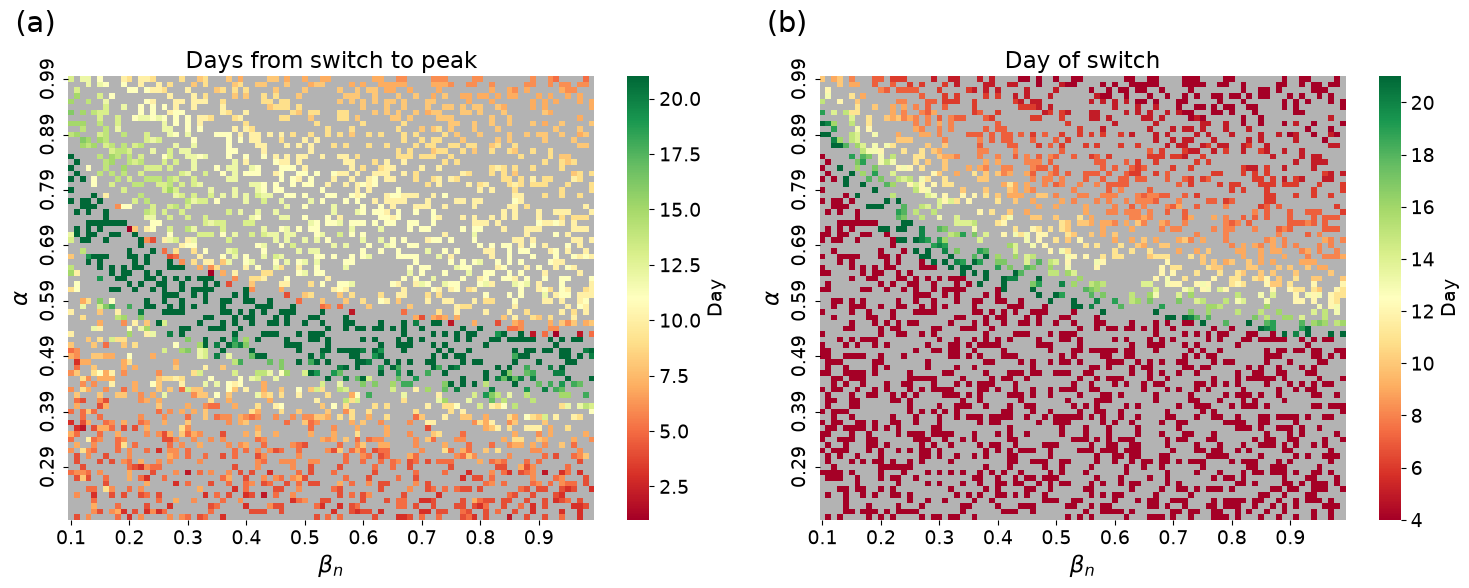

In [28]:
# paper: fig.7
server.plot_heatmap_switch(topology='ba')